In [ ]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import mujoco
from IPython.display import display as ipy_display
plt.rcParams.update({"figure.dpi": 110, "figure.facecolor": "white"})

from yaml_loader import load_task
from scenes import SimpleLegoScene
from bridges import LegoCoarseSimpleSLSBridge, LegoCoarseSimpleV2SLSBridge, execute_plan

In [2]:
def _free_cam(env, lookat, distance, azimuth, elevation):
    cam = mujoco.MjvCamera(); mujoco.mjv_defaultFreeCamera(env.get_model(), cam)
    cam.lookat[:] = np.asarray(lookat, float)
    cam.distance, cam.azimuth, cam.elevation = distance, azimuth, elevation
    return cam

def _render(env, cam, width=640, height=480):
    env.forward(); r = mujoco.Renderer(env.get_model(), height=height, width=width)
    r.update_scene(env.get_data(), camera=cam); img = r.render(); r.close(); return img

def _show(img, title):
    fig, ax = plt.subplots(figsize=(5, 4)); ax.imshow(img); ax.axis("off")
    ax.set_title(title, fontsize=10); fig.tight_layout(); ipy_display(fig); plt.close(fig)

def ee_position(env):
    sid = mujoco.mj_name2id(env.get_model(), mujoco.mjtObj.mjOBJ_SITE, "attachment_site")
    env.forward(); return env.get_data().site_xpos[sid].copy()

def show_scene(env, title="Scene", distance=1.3, azimuth=135, elevation=-25, center=None):
    _show(_render(env, _free_cam(env, center if center is not None else _table_center, distance, azimuth, elevation)), title)

def show_top_view(env, center=None, distance=0.75, title="Top-down view"):
    _show(_render(env, _free_cam(env, center if center is not None else _table_center, distance, 90, -89)), title)

def show_ee_top_view(env, distance=0.35, title="End-effector (top-down)"):
    show_top_view(env, ee_position(env), distance, title)

def show_object_top_view(env, name, distance=0.22, title=None):
    show_top_view(env, env.get_object_position(name), distance, title or f"{name} (top-down)")

print("Visualisation helpers ready \u2713")

Visualisation helpers ready ✓


In [ ]:
SEED = 42
TASK = "dataset/ground_truth/tier3/task_001.yaml"
bricks, lat = load_task(TASK, TASK)
scene = SimpleLegoScene(bricks, seed=42)
scene.env.ik.solver = "daqp"
_table_center = (*scene.layout.asm_center, scene.table_z)   # used by the render helpers above
bricks

[Brick(name='4x2_brick_1', type='brick_4x2', color='red', layer=0, yaw=0, cells=frozenset({(-3, 8), (-2, 8), (-1, 8), (0, 9), (-3, 9), (-2, 9), (-1, 9), (0, 8)}), anchor=(-3, 8), center=(-0.016, 0.148, 0.0), initial=(0.2552, -0.1148, 0.0495), initial_yaw=0),
 Brick(name='4x2_brick_2', type='brick_4x2', color='red', layer=0, yaw=0, cells=frozenset({(-5, 7), (-4, 7), (-3, 7), (-6, 7), (-5, 6), (-4, 6), (-6, 6), (-3, 6)}), anchor=(-6, 6), center=(-0.064, 0.116, 0.0), initial=(0.5057, -0.1229, 0.0495), initial_yaw=0),
 Brick(name='2x2_brick_3', type='brick_2x2', color='red', layer=1, yaw=0, cells=frozenset({(-3, 8), (-4, 7), (-4, 8), (-3, 7)}), anchor=(-4, 7), center=(-0.048, 0.132, 0.0191), initial=(0.2561, -0.2166, 0.0495), initial_yaw=0),
 Brick(name='4x2_brick_4', type='brick_4x2', color='yellow', layer=2, yaw=90, cells=frozenset({(-3, 8), (-4, 7), (-3, 7), (-4, 9), (-3, 9), (-4, 6), (-3, 6), (-4, 8)}), anchor=(-4, 6), center=(-0.048, 0.132, 0.0382), initial=(0.3759, -0.1276, 0.0495), 

NOTE: 2x2_brick_3 rests on ['4x2_brick_2', '4x2_brick_1']; keeping only 4x2_brick_2 (see bridge limitation)
objects: {'brick': ['b_4x2_brick_1', 'b_4x2_brick_2', 'b_2x2_brick_3', 'b_4x2_brick_4', 'b_4x2_brick_5']}
goals:   [('at-target', 'b_4x2_brick_1'), ('at-target', 'b_4x2_brick_2'), ('at-target', 'b_2x2_brick_3'), ('at-target', 'b_4x2_brick_4'), ('at-target', 'b_4x2_brick_5'), ('stacked_on', 'b_2x2_brick_3', 'b_4x2_brick_2'), ('stacked_on', 'b_4x2_brick_4', 'b_2x2_brick_3'), ('stacked_on', 'b_4x2_brick_5', 'b_4x2_brick_2')]


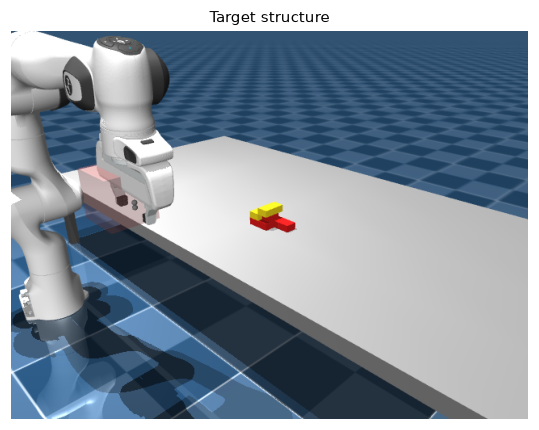

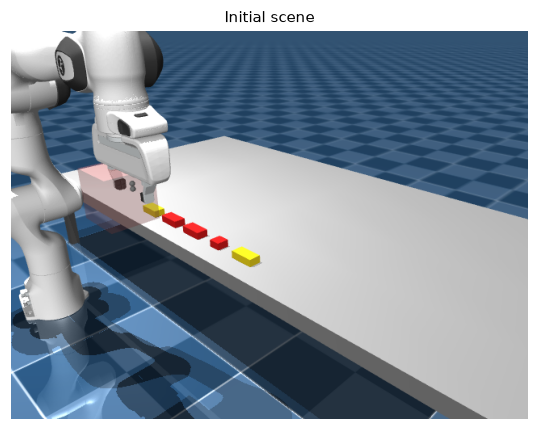

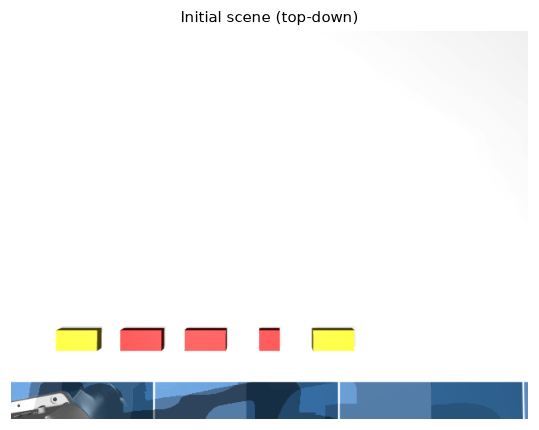

NOTE: To disable printing of planning engine credits, add this line to your code: `up.shortcuts.get_environment().credits_stream = None`
  *** Credits ***
  * In operation mode `OneshotPlanner` at line 395 of `/Users/maxazvd/uni/sem3/aifr/lego-workbenchmark/lego-workbenchmark/src/tampanda/tamp/domain_bridge.py`, you are using the following planning engine:
  * Engine name: pyperplan
  * Developers:  Albert-Ludwigs-Universität Freiburg (Yusra Alkhazraji, Matthias Frorath, Markus Grützner, Malte Helmert, Thomas Liebetraut, Robert Mattmüller, Manuela Ortlieb, Jendrik Seipp, Tobias Springenberg, Philip Stahl, Jan Wülfing)
  * Description: Pyperplan is a lightweight STRIPS planner written in Python.


PLAN:
None


In [ ]:
from bridges import LegoCoarseSimpleV2SLSWeldBridge

# try new domain/bridge
bridge = LegoCoarseSimpleV2SLSWeldBridge.make_bridge("domains/lego_coarse_simple_v2.pddl", scene)
objects, goals = LegoCoarseSimpleV2SLSWeldBridge.build_objects_and_goal(bricks)
print("objects:", objects)
print("goals:  ", goals)

scene.to_target_structure()
show_scene(scene.env, "Target structure")
scene.env.reset()
# scene.env.rest(1.0)

show_scene(scene.env, "Initial scene")
show_top_view(scene.env, title="Initial scene (top-down)")
plan = bridge.plan(objects, goals)
print("\nPLAN:")
print(plan)

In [ ]:
from bridges import LegoBeyondTier2SLSWeldBridge

# try new domain/bridge
# bridge = LegoBeyondTier2SLSWeldBridge.make_bridge("domains/lego_beyond_tier2.pddl", scene)
# objects, goals = LegoBeyondTier2SLSWeldBridge.build_objects_and_goal(bricks)
# print("objects:", objects)
# print("goals:  ", goals)
# 
# scene.to_target_structure()
# show_scene(scene.env, "Target structure")
# scene.env.reset()
# # scene.env.rest(1.0)
# 
# show_scene(scene.env, "Initial scene")
# show_top_view(scene.env, title="Initial scene (top-down)")
# plan = bridge.plan(objects, goals)
# print("\nPLAN:")
# print(plan)

## lego_beyond_tier2_slots domain

### First Test on T3

In [6]:
TASK = "dataset/ground_truth/tier3/task_001.yaml"
bricks, lat = load_task(TASK, TASK)
scene = SimpleLegoScene(bricks, seed=42)
scene.env.ik.solver = "daqp"
_table_center = (*scene.layout.asm_center, scene.table_z)   # used by the render helpers above
bricks

[Brick(name='4x2_brick_1', type='brick_4x2', color='red', layer=0, yaw=0, cells=frozenset({(-3, 8), (-2, 8), (-1, 8), (0, 9), (-3, 9), (-2, 9), (-1, 9), (0, 8)}), anchor=(-3, 8), center=(-0.016, 0.148, 0.0), initial=(0.2552, -0.1148, 0.0495), initial_yaw=0),
 Brick(name='4x2_brick_2', type='brick_4x2', color='red', layer=0, yaw=0, cells=frozenset({(-5, 7), (-4, 7), (-3, 7), (-6, 7), (-5, 6), (-4, 6), (-6, 6), (-3, 6)}), anchor=(-6, 6), center=(-0.064, 0.116, 0.0), initial=(0.5057, -0.1229, 0.0495), initial_yaw=0),
 Brick(name='2x2_brick_3', type='brick_2x2', color='red', layer=1, yaw=0, cells=frozenset({(-3, 8), (-4, 7), (-4, 8), (-3, 7)}), anchor=(-4, 7), center=(-0.048, 0.132, 0.0191), initial=(0.2561, -0.2166, 0.0495), initial_yaw=0),
 Brick(name='4x2_brick_4', type='brick_4x2', color='yellow', layer=2, yaw=90, cells=frozenset({(-3, 8), (-4, 7), (-3, 7), (-4, 9), (-3, 9), (-4, 6), (-3, 6), (-4, 8)}), anchor=(-4, 6), center=(-0.048, 0.132, 0.0382), initial=(0.3759, -0.1276, 0.0495), 

#### Generate Plan

objects: {'brick': ['b_4x2_brick_1', 'b_4x2_brick_2', 'b_2x2_brick_3', 'b_4x2_brick_4', 'b_4x2_brick_5', 'filler_1', 'filler_2', 'filler_3', 'filler_4', 'filler_5']}
goals:   [('at-target', 'b_4x2_brick_1'), ('at-target', 'b_4x2_brick_2'), ('at-target', 'b_2x2_brick_3'), ('at-target', 'b_4x2_brick_4'), ('at-target', 'b_4x2_brick_5')]


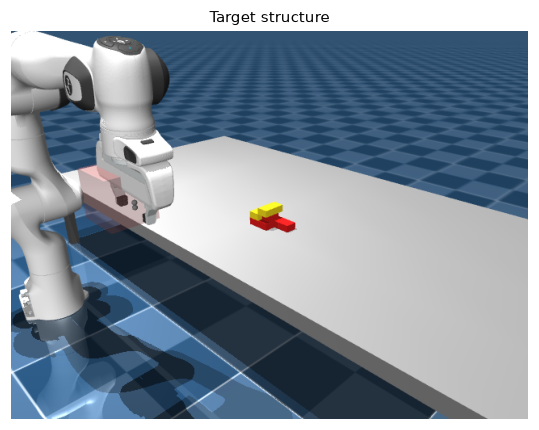

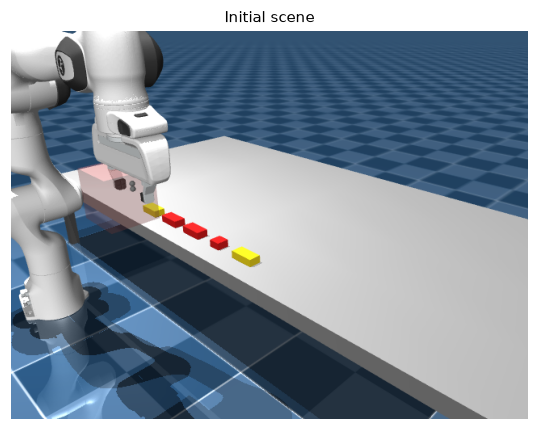

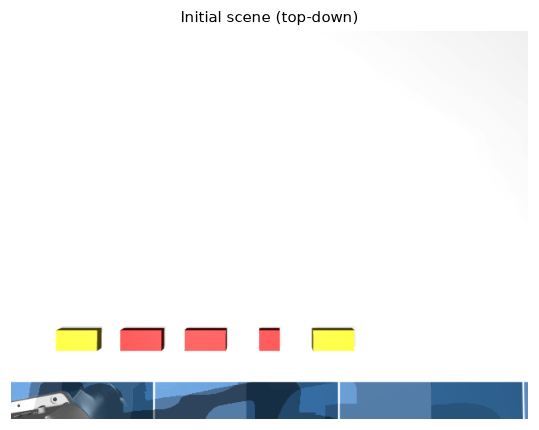

  *** Credits ***
  * In operation mode `OneshotPlanner` at line 395 of `/Users/maxazvd/uni/sem3/aifr/lego-workbenchmark/lego-workbenchmark/src/tampanda/tamp/domain_bridge.py`, you are using the following planning engine:
  * Engine name: pyperplan
  * Developers:  Albert-Ludwigs-Universität Freiburg (Yusra Alkhazraji, Matthias Frorath, Markus Grützner, Malte Helmert, Thomas Liebetraut, Robert Mattmüller, Manuela Ortlieb, Jendrik Seipp, Tobias Springenberg, Philip Stahl, Jan Wülfing)
  * Description: Pyperplan is a lightweight STRIPS planner written in Python.

Planned for 0.071s

PLAN:
  ('prepare_place', ('b_4x2_brick_2', 'filler_1', 'filler_2', 'filler_3', 'filler_4', 'filler_5'))
  ('prepare_place', ('b_4x2_brick_1', 'filler_1', 'filler_2', 'filler_3', 'filler_4', 'filler_5'))
  ('pick', ('b_4x2_brick_2',))
  ('place', ('b_4x2_brick_2',))
  ('prepare_place', ('b_4x2_brick_5', 'b_4x2_brick_2', 'filler_2', 'filler_3', 'filler_4', 'filler_5'))
  ('pick', ('b_4x2_brick_1',))
  ('place'

In [ ]:
from bridges import LegoBeyondTier2SlotsSLSWeldBridge
import time

# try new domain/bridge
bridge = LegoBeyondTier2SlotsSLSWeldBridge.make_bridge("domains/lego_beyond_tier2_slots.pddl", scene)
objects, goals = LegoBeyondTier2SlotsSLSWeldBridge.build_objects_and_goal(bricks)
print("objects:", objects)
print("goals:  ", goals)

scene.to_target_structure()
show_scene(scene.env, "Target structure")
scene.env.reset()
# scene.env.rest(1.0)

show_scene(scene.env, "Initial scene")
show_top_view(scene.env, title="Initial scene (top-down)")

start_t = time.time()
plan = bridge.plan(objects, goals)
wall_time = time.time() - start_t
print(f"Planned for {wall_time:.3f}s")
print("\nPLAN:")
for step in plan:
    print(" ", step)

#### Execute Plan

In [8]:
# ok, n = True, 0
# for i, (name, args) in enumerate(plan):
#     success, _ = bridge.execute_action(name, *args)
#     print(f"[{i+1}/{len(plan)}] {name}({', '.join(args)}) -> {'ok' if success else 'FAILED'}")
#     show_scene(scene.env, f"after {name}({', '.join(args)})")
#     if not success:
#         ok, n = False, i
#         break
# else:
#     n = len(plan)
# 
# print("\nexecuted:", ok)
# succeeded, _ = scene.check_goal()
# print(f"{succeeded = }")

### Sample test over T2

In [9]:
# import glob
# import random
# 
# NUM_TESTS = 20
# 
# random.seed(42)
# 
# tasks = glob.glob("dataset/ground_truth/tier2/task_*.yaml")
# samples = []
# for i in range(NUM_TESTS):
#     ind = random.randint(0, len(tasks))
#     samples.append(tasks.pop(ind))
# 
# results = []
# 
# for i, task in enumerate(sorted(samples)):
#     print(f"[{i+1}/{NUM_TESTS}]: setting up {task}")
#     bricks, lat = load_task(task, task)
#     scene = SimpleLegoScene(bricks, seed=SEED)
#     scene.env.ik.solver = "daqp"
#     _table_center = (*scene.layout.asm_center, scene.table_z)   # used by the render helpers above
# 
#     bridge = LegoBeyondTier2SlotsSLSWeldBridge.make_bridge("domains/lego_beyond_tier2_slots.pddl", scene)
#     objects, goals = LegoBeyondTier2SlotsSLSWeldBridge.build_objects_and_goal(bricks)
#     # print("objects:", objects)
#     # print("goals:  ", goals)
# 
#     plan = bridge.plan(objects, goals)
#     execute_plan(bridge, plan)
#     success, _ = scene.check_goal()
#     results.append(success)
#     print(f"\nsuccess: {success}")
#     print("\n\n")

In [10]:
all(results)

NameError: name 'results' is not defined

### Full sweep of T3

In [11]:
import glob
# tasks = glob.glob("dataset/ground_truth/tier3/task_*.yaml")
# 
# results = []
# 
# for i, task in enumerate(sorted(tasks)):
#     print(f"[{i+1}/{len(tasks)}]: setting up {task}")
#     bricks, lat = load_task(task, task)
#     scene = SimpleLegoScene(bricks, seed=SEED)
#     scene.env.ik.solver = "daqp"
#     _table_center = (*scene.layout.asm_center, scene.table_z)   # used by the render helpers above
# 
#     bridge = LegoBeyondTier2SlotsSLSWeldBridge.make_bridge("domains/lego_beyond_tier2_slots.pddl", scene)
#     objects, goals = LegoBeyondTier2SlotsSLSWeldBridge.build_objects_and_goal(bricks)
# 
#     plan_start_t = time.time()
#     plan = bridge.plan(objects, goals)
#     plan_wall_time = time.time() - plan_start_t
#     print(f"Planning took {plan_wall_time:.3f}s")
# 
#     sim_start_t = time.time()
#     execute_plan(bridge, plan)
#     sim_wall_time = time.time() - sim_start_t
#     print(f"Sim took {sim_wall_time:.3f}s")
# 
#     success, _ = scene.check_goal()
# 
#     results.append({
#         "task": task,
#         "plan_wall_time": plan_wall_time,
#         "sim_wall_time": sim_wall_time,
#         "plan": plan,
#         "success": success,
#     })
# 
#     print(f"\nsuccess: {success}")
#     print("\n\n")

- a lot seem to be failing at pick, prolly because out of reach
- => now pick_slots in Layout
- but what if some brick placed and that placed brick now obstructs approach of pick spot...

In [12]:
len([1 for d in results if d["success"]]), len(results)

NameError: name 'results' is not defined

In [ ]:
results

[{'task': 'dataset/ground_truth/tier3/task_001.yaml',
  'plan_wall_time': 0.06703686714172363,
  'sim_wall_time': 74.17921495437622,
  'plan': [('prepare_place',
    ('b_4x2_brick_2',
     'filler_1',
     'filler_2',
     'filler_3',
     'filler_4',
     'filler_5')),
   ('prepare_place',
    ('b_4x2_brick_1',
     'filler_1',
     'filler_2',
     'filler_3',
     'filler_4',
     'filler_5')),
   ('pick', ('b_4x2_brick_2',)),
   ('place', ('b_4x2_brick_2',)),
   ('prepare_place',
    ('b_4x2_brick_5',
     'b_4x2_brick_2',
     'filler_2',
     'filler_3',
     'filler_4',
     'filler_5')),
   ('pick', ('b_4x2_brick_1',)),
   ('place', ('b_4x2_brick_1',)),
   ('prepare_place',
    ('b_2x2_brick_3',
     'b_4x2_brick_2',
     'b_4x2_brick_1',
     'filler_3',
     'filler_4',
     'filler_5')),
   ('pick', ('b_2x2_brick_3',)),
   ('place', ('b_2x2_brick_3',)),
   ('prepare_place',
    ('b_4x2_brick_4',
     'b_2x2_brick_3',
     'filler_2',
     'filler_3',
     'filler_4',
     'f

### (Suspected) Issues Above:
- when placing brick the gripper could be obstructed by (x,y)-neighboring bricks:
  - new domain with (brick, brick) predicates x_neighbor, y_neighbor
  - => if in target structure one brick is right next to other in x, y plane
  - then add place_x/place_y actions where precon is that no x neighbor placed (or y for place_y)
  - we thus have two ordering constraints when placing bricks:
    - supporter DAG ordering (physics constraint): supporters of brick placed before brick can be placed (lego_beyond_tie2_slots.pddl)
    - neighbor order (gripper constraint): brick can only be placed if one axis is free for gripper to descend and place brick to (TODO new domain)
- pick slots still having issues (based on pick failures)
  - NOT VERIFIED but suspect that when some brick placed in target structure could obstruct picking brick in pick slots
    - shouldnt need some domain fix here, we should just find good pick slots and asm_center

need to verify by actually running the failed tasks and looking at demo

In [16]:
import pandas as pd
# 
# results_no_plan = []
# for r in results:
#     d = dict(r)
#     d.pop("plan")
#     results_no_plan.append(d)

# t3_res_df = pd.DataFrame(results_no_plan)
t3_res_df = pd.read_csv("generated/evals/slots_t3.csv")
# t3_res_df.to_csv("generated/evals/slots_t3.csv")

In [17]:
failed_df = t3_res_df[t3_res_df.success == False]
failed_df

,Unnamed: 0,task,plan_wall_time,sim_wall_time,success
2,2,dataset/ground_truth/tier3/task_003.yaml,0.092955,49.941304,False
4,4,dataset/ground_truth/tier3/task_005.yaml,0.060118,26.122780,False
17,17,dataset/ground_truth/tier3/task_018.yaml,0.080970,103.738123,False
19,19,dataset/ground_truth/tier3/task_020.yaml,0.120102,129.847951,False
20,20,dataset/ground_truth/tier3/task_021.yaml,0.046602,40.904893,False
24,24,dataset/ground_truth/tier3/task_025.yaml,0.058097,33.335555,False
33,33,dataset/ground_truth/tier3/task_034.yaml,0.063227,29.631195,False
34,34,dataset/ground_truth/tier3/task_035.yaml,0.316785,38.138099,False
36,36,dataset/ground_truth/tier3/task_037.yaml,0.089532,143.823770,False
37,37,dataset/ground_truth/tier3/task_038.yaml,0.250524,29.807975,False


In [ ]:
import imageio  # pip install ImageIO
 
def frames_to_mp4(frames, path, fps=15):
    imageio.mimwrite(path, frames, fps=fps, codec="libx264", quality=8)
 
def frames_to_gif(frames, path, fps=10):
    imageio.mimsave(path, frames, fps=fps)


Unnamed: 0                                              17
task              dataset/ground_truth/tier3/task_018.yaml
plan_wall_time                                     0.08097
sim_wall_time                                   103.738123
success                                              False
Name: 17, dtype: object
  *** Credits ***
  * In operation mode `OneshotPlanner` at line 395 of `/Users/maxazvd/uni/sem3/aifr/lego-workbenchmark/lego-workbenchmark/src/tampanda/tamp/domain_bridge.py`, you are using the following planning engine:
  * Engine name: pyperplan
  * Developers:  Albert-Ludwigs-Universität Freiburg (Yusra Alkhazraji, Matthias Frorath, Markus Grützner, Malte Helmert, Thomas Liebetraut, Robert Mattmüller, Manuela Ortlieb, Jendrik Seipp, Tobias Springenberg, Philip Stahl, Jan Wülfing)
  * Description: Pyperplan is a lightweight STRIPS planner written in Python.

Planning took 0.209s


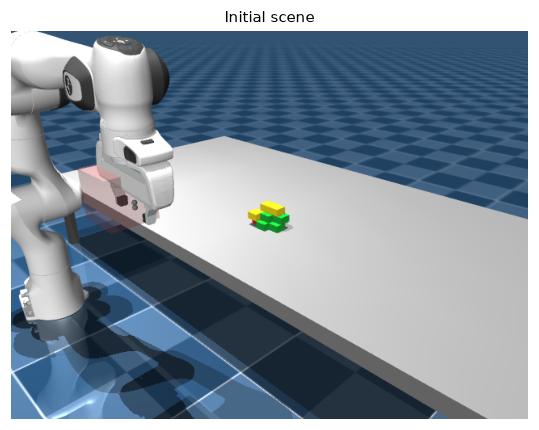

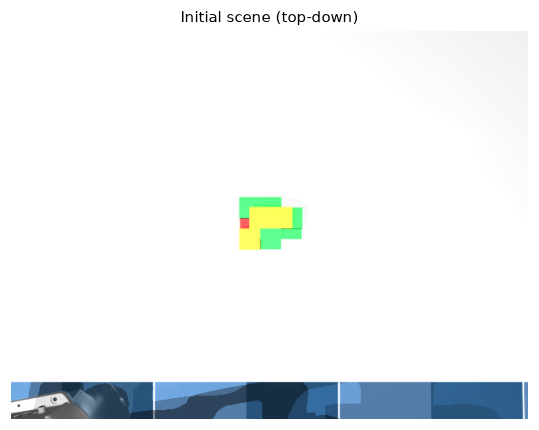

[1/24] prepare_place(b_4x2_brick_2, filler_1, filler_2, filler_3, filler_4, filler_5) -> ok
[2/24] prepare_place(b_2x2_brick_1, filler_1, filler_2, filler_3, filler_4, filler_5) -> ok
[3/24] prepare_place(b_2x2_brick_3, filler_1, filler_2, filler_3, filler_4, filler_5) -> ok
[PickPlaceExecutor] Trying candidate 1/2: top_down_x
  EE error at grasp: 1.1 mm
  pick SUCCESS
[4/24] pick(b_4x2_brick_2) -> ok
[5/24] place(b_4x2_brick_2) -> ok
[6/24] prepare_place(b_4x2_brick_5, b_4x2_brick_2, filler_2, filler_3, filler_4, filler_5) -> ok
[7/24] prepare_place(b_2x2_brick_8, b_4x2_brick_2, filler_2, filler_3, filler_4, filler_5) -> ok
[PickPlaceExecutor] Trying candidate 1/2: top_down_x
  EE error at grasp: 1.5 mm
  pick SUCCESS
[8/24] pick(b_2x2_brick_1) -> ok
[9/24] place(b_2x2_brick_1) -> ok
[10/24] prepare_place(b_2x2_brick_4, b_2x2_brick_1, filler_2, filler_3, filler_4, filler_5) -> ok
[PickPlaceExecutor] Trying candidate 1/2: top_down_x
  EE error at grasp: 1.0 mm
  pick SUCCESS
[11/24] pi

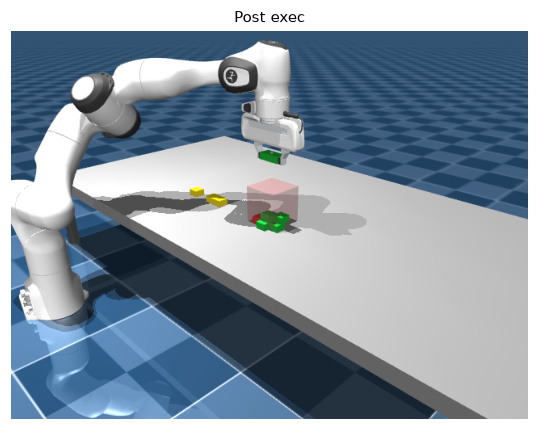

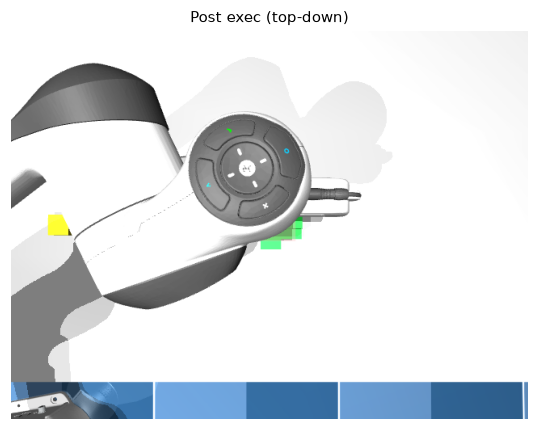

In [38]:
for index, row in list(failed_df.iterrows())[2:]:
    print(row)
    task = row["task"]

    bricks, lat = load_task(task, task)
    scene = SimpleLegoScene(bricks, seed=SEED)
    scene.env.ik.solver = "daqp"
    _table_center = (*scene.layout.asm_center, scene.table_z)   # used by the render helpers above

    bridge = LegoBeyondTier2SlotsSLSWeldBridge.make_bridge("domains/lego_beyond_tier2_slots.pddl", scene)
    objects, goals = LegoBeyondTier2SlotsSLSWeldBridge.build_objects_and_goal(bricks)

    plan_start_t = time.time()
    plan = bridge.plan(objects, goals)
    plan_wall_time = time.time() - plan_start_t
    print(f"Planning took {plan_wall_time:.3f}s")

    scene.to_target_structure()
    show_scene(scene.env, "Initial scene")
    show_top_view(scene.env, title="Initial scene (top-down)")
    scene.env.reset()
    scene.env.rest(1.0)

    scene.start_recording(every_n_steps=20)   # also get a file out of the same run
    sim_start_t = time.time()
    execute_plan(bridge, plan)
    sim_wall_time = time.time() - sim_start_t
    print(f"Sim took {sim_wall_time:.3f}s")
    frames = scene.stop_recording()

    show_scene(scene.env, "Post exec")
    show_top_view(scene.env, title="Post exec (top-down)")

    success, _ = scene.check_goal()
    if not success:
        break


In [39]:
# pip install "imageio[ffmpeg]"
frames_to_mp4(frames, "generated/demos/slots_bad_layer_order.mp4")

### Identified Issue
- bricks were placed badly (see generated/demos/test_)
- in second layer shoulve placed 4x2 brick first, then the middle 2x2 with x-axis grasp and then other 2x2 with y-axis grasp